# 01 - Exploracion de datos: Amazon Video Games

Objetivo: entender la calidad y estructura del dataset antes de decidir la limpieza para el sistema de recomendacion.

Preguntas guia:

- Que columnas son utiles para el recomendador?
- Cuantos nulos, duplicados o valores fuera de rango hay?
- Como se distribuyen ratings, usuarios, productos y fechas?
- Que reglas de limpieza conservan suficientes datos sin introducir ruido?

## 1. Setup

Este notebook esta pensado para ejecutarse desde `kedro jupyter lab` o directamente desde Jupyter. Si el catalogo de Kedro no esta disponible, carga el parquet crudo desde `data/01_raw/video_games.parquet`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "01_raw" / "video_games.parquet"

# Algunas comprobaciones exactas requieren shuffles grandes. Por defecto se dejan desactivadas
# para que el notebook sea ejecutable en local con el dataset completo.
RUN_EXPENSIVE_CHECKS = False
SAMPLE_FRACTION = 0.05

PROJECT_ROOT, RAW_DATA_PATH

(WindowsPath('C:/Users/ander/amazon-recsys'),
 WindowsPath('C:/Users/ander/amazon-recsys/data/01_raw/video_games.parquet'))

In [ ]:
import os

# 1. Fix de red
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"

# 2. Inicializamos Spark con los seguros activados
spark = (
    SparkSession.builder
    .appName("amazon-recsys-data-exploration")
    .master("local[4]")
    .config("spark.driver.host", "127.0.0.1")        
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark

In [3]:
try:
    from kedro.framework.session import KedroSession
    from kedro.framework.startup import bootstrap_project

    metadata = bootstrap_project(PROJECT_ROOT)
    with KedroSession.create(project_path=PROJECT_ROOT) as session:
        context = session.load_context()
        catalog = context.catalog
        df = catalog.load("amazon_reviews")
    print("Dataset cargado desde Kedro catalog: amazon_reviews")
except Exception as exc:
    print(f"No se pudo usar Kedro catalog ({type(exc).__name__}: {exc}). Cargando parquet directamente.")
    df = spark.read.parquet(str(RAW_DATA_PATH))

raw_columns = df.columns
analysis_columns = [
    "rating",
    "asin",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase",
]
analysis_columns = [column for column in analysis_columns if column in raw_columns]
df = df.select(*analysis_columns)

# No cacheamos el DataFrame completo: el parquet crudo contiene columnas de texto e imagenes
# que pueden agotar la memoria local. El EDA principal usa columnas ligeras con pushdown.

[04/30/26 12:36:36] INFO     Using                                                                  ]8;id=139049;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=139050;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\framework\project\__init__.py#275\275]8;;\
                             'C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\framework\                
                             project\rich_logging.yml' as logging configuration.                                   

[04/30/26 12:36:37] INFO     No typed parameter requirements found, returning original   ]8;id=139057;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=139058;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=139065;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=139066;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[04/30/26 12:36:38] INFO     Loading data from amazon_reviews (SparkDataset)...                ]8;id=139073;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=139074;file://C:\Users\ander\amazon-recsys\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

Dataset cargado desde Kedro catalog: amazon_reviews


## 2. Vista general

Primero comprobamos volumen, esquema y unas filas de muestra. Esto ayuda a confirmar si las columnas esperadas para el recomendador existen: `user_id`, `parent_asin` y `rating`.

In [4]:
n_rows = df.count()
n_cols = len(df.columns)

print(f"Filas: {n_rows:,}")
print(f"Columnas: {n_cols:,}")
df.printSchema()

Filas: 4,624,615
Columnas: 7
root
 |-- rating: double (nullable = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [5]:
df.limit(5).toPandas()

,rating,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4.0,B07DJWBYKP,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1608186804795,0,True
1,5.0,B00ZS80PC2,B07SRWRH5D,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1587051114941,1,False
2,5.0,B01FEHJYUU,B07MFMFW34,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,1490877431000,0,True
3,5.0,B07GXJHRVK,B0BCHWZX95,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,1577637634017,0,True
4,5.0,B00HUWA45W,B00HUWA45W,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,1427591932000,0,True


In [6]:
expected_columns = ["user_id", "asin", "parent_asin", "rating", "timestamp", "verified_purchase", "helpful_vote", "title", "text", "images"]
pd.DataFrame(
    {
        "column": expected_columns,
        "exists_in_raw": [column in raw_columns for column in expected_columns],
        "used_in_main_eda": [column in df.columns for column in expected_columns],
    }
)

,column,exists_in_raw,used_in_main_eda
0,user_id,True,True
1,asin,True,True
2,parent_asin,True,True
3,rating,True,True
4,timestamp,True,True
5,verified_purchase,True,True
6,helpful_vote,True,True
7,title,True,False
8,text,True,False
9,images,True,False


## 3. Nulos y cadenas vacias

Para ALS y otros recomendadores colaborativos, los campos minimos son usuario, item y rating. Las columnas de texto pueden ser utiles para analisis posterior, pero no deben bloquear el dataset base si estan vacias.

In [7]:
missing_exprs = []
for column_name, dtype in df.dtypes:
    is_missing = F.col(column_name).isNull()
    if dtype == "string":
        is_missing = is_missing | (F.trim(F.col(column_name)) == "")
    missing_exprs.append(F.sum(F.when(is_missing, 1).otherwise(0)).alias(column_name))

missing_pd = df.select(missing_exprs).toPandas().T.reset_index()
missing_pd.columns = ["column", "missing_rows"]
missing_pd["missing_pct"] = missing_pd["missing_rows"] / n_rows
missing_pd.sort_values("missing_pct", ascending=False)

,column,missing_rows,missing_pct
0,rating,0,0.0
1,asin,0,0.0
2,parent_asin,0,0.0
3,user_id,0,0.0
4,timestamp,0,0.0
5,helpful_vote,0,0.0
6,verified_purchase,0,0.0


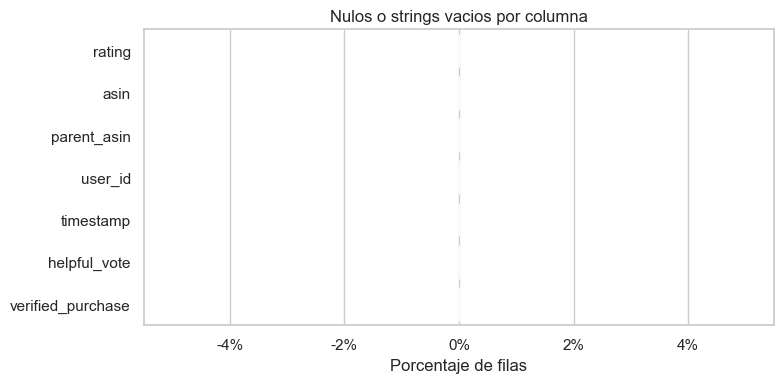

In [8]:
plot_df = missing_pd.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="missing_pct", y="column", color="#4C78A8")
plt.gca().xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.xlabel("Porcentaje de filas")
plt.ylabel("")
plt.title("Nulos o strings vacios por columna")
plt.tight_layout()

Decision provisional:

- `user_id`, `parent_asin` y `rating` no deberian tener nulos en el dataset modelable.
- `title`, `text` e `images` pueden conservarse para EDA o modelos hibridos, pero no son obligatorias para ALS.
- `asin` identifica variantes concretas; `parent_asin` agrupa producto padre y suele ser mejor item para recomendacion.

## 4. Ratings

Revisamos rango, valores invalidos y distribucion. El pipeline actual castea `rating` a `float`; antes de limpiar conviene comprobar que todos los valores estan en la escala esperada.

In [9]:
rating_summary = df.select(
    F.count("rating").alias("non_null_ratings"),
    F.min("rating").alias("min_rating"),
    F.max("rating").alias("max_rating"),
    F.mean("rating").alias("mean_rating"),
    F.stddev("rating").alias("std_rating"),
    F.sum(F.when((F.col("rating") < 1) | (F.col("rating") > 5), 1).otherwise(0)).alias("out_of_range"),
).toPandas()

rating_summary

,non_null_ratings,min_rating,max_rating,mean_rating,std_rating,out_of_range
0,4624615,1.0,5.0,4.04746,1.430443,0


In [10]:
rating_dist = (
    df.groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)
rating_dist["pct"] = rating_dist["count"] / rating_dist["count"].sum()
rating_dist

,rating,count,pct
0,1.0,589519,0.127474
1,2.0,249878,0.054032
2,3.0,340086,0.073538
3,4.0,617251,0.133471
4,5.0,2827881,0.611485


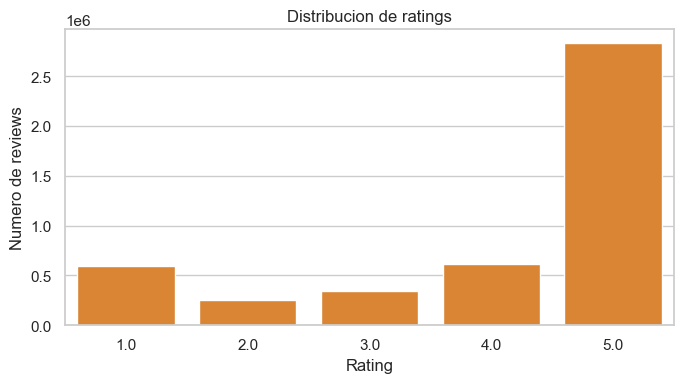

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(data=rating_dist, x="rating", y="count", color="#F58518")
plt.xlabel("Rating")
plt.ylabel("Numero de reviews")
plt.title("Distribucion de ratings")
plt.tight_layout()

## 5. Fechas y actividad temporal

`timestamp` viene en milisegundos Unix. Convertirlo permite detectar periodos raros, cambios de volumen y posibles filtros temporales para train/test.

In [12]:
df_dates = df.withColumn("review_date", F.to_date(F.from_unixtime(F.col("timestamp") / 1000)))

date_summary = df_dates.select(
    F.min("review_date").alias("min_date"),
    F.max("review_date").alias("max_date"),
    F.sum(F.when(F.col("timestamp").isNull(), 1).otherwise(0)).alias("missing_timestamp"),
).toPandas()

date_summary

,min_date,max_date,missing_timestamp
0,1998-11-17,2023-09-12,0


,year,count
16,2014,323494
17,2015,410496
18,2016,390284
19,2017,364203
20,2018,379516
21,2019,447326
22,2020,521375
23,2021,479619
24,2022,399141
25,2023,180608


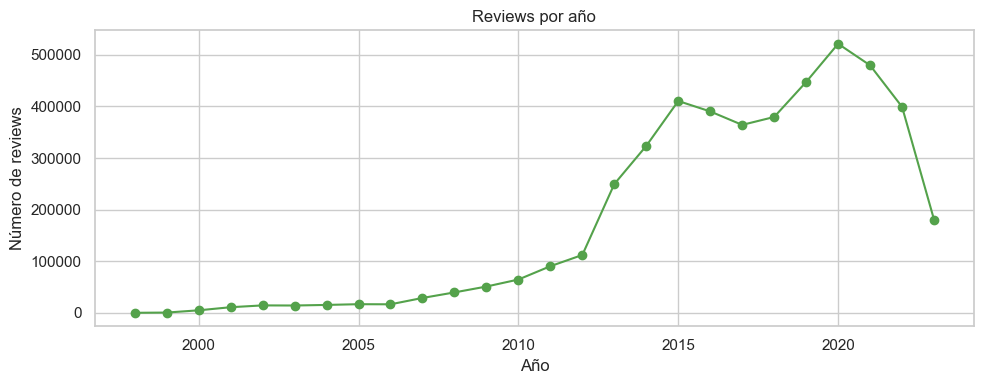

In [13]:
reviews_by_year = (
    df_dates.withColumn("year", F.year("review_date"))
    .groupBy("year")
    .count()
    .orderBy("year")
    .toPandas()
)

plt.figure(figsize=(10, 4))
plt.plot(reviews_by_year["year"], reviews_by_year["count"], marker="o", color="#54A24B")
plt.xlabel("Año")
plt.ylabel("Número de reviews")
plt.title("Reviews por año")
plt.tight_layout()

reviews_by_year.tail(10)


## 6. Duplicados

Hay varias definiciones posibles de duplicado. Para recomendacion suele importar si el mismo usuario valora el mismo producto padre mas de una vez. En ese caso se puede conservar la review mas reciente o agregar ratings.

In [14]:
duplicate_source = df.select("user_id", "parent_asin", "rating", "timestamp")

if RUN_EXPENSIVE_CHECKS:
    duplicate_scope = duplicate_source
    scope_label = "full_dataset"
    scope_rows = n_rows
    full_duplicate_rows = n_rows - duplicate_source.dropDuplicates().count()
else:
    duplicate_scope = duplicate_source.sample(False, SAMPLE_FRACTION, seed=42)
    scope_label = f"sample_{SAMPLE_FRACTION:.0%}"
    scope_rows = duplicate_scope.count()
    full_duplicate_rows = None

duplicate_keys = (
    duplicate_scope.groupBy("user_id", "parent_asin")
    .count()
    .filter(F.col("count") > 1)
)

duplicate_key_summary = duplicate_keys.select(
    F.count("*").alias("duplicated_user_item_pairs"),
    F.sum("count").alias("rows_in_duplicated_pairs"),
    F.max("count").alias("max_reviews_same_user_item"),
).toPandas()

pd.DataFrame(
    {
        "metric": ["scope", "scope_rows", "full_duplicate_rows", *duplicate_key_summary.columns.tolist()],
        "value": [scope_label, scope_rows, full_duplicate_rows, *duplicate_key_summary.iloc[0].tolist()],
    }
)

,metric,value
0,scope,sample_5%
1,scope_rows,230716
2,full_duplicate_rows,None
3,duplicated_user_item_pairs,207
4,rows_in_duplicated_pairs,417
5,max_reviews_same_user_item,3


In [15]:
(
    duplicate_scope.groupBy("user_id", "parent_asin")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)

,user_id,parent_asin,count
0,AGM4AUOGIIUEIYC67RNMNXSBSI5Q,B06XHMPPLH,3
1,AFR4IKYT3BZRTACEB7YMMWXRVKUQ,B00EP2WNKY,3
2,AGDY6CSODBPZQSFEPWZLO2OZWSDQ,B00EP2WNKY,3
3,AH6B2TK4OXK5TJ34BQK3QNTYKNKQ,B07K3KHFSY,2
4,AGNM7ZHBHTJDMAT74D4PQ2MDYFHQ,B00R0ZS9YW,2
5,AE4B76GV4BNPPBQOQPYUANDIODYQ,B00BALK9CM,2
6,AFDMDLZ27KTGKTZYIKPF3OVZA4LA,B088R2CTVG,2
7,AE4MI6MKLV2G3OSKZRIMOHSUSY4Q,B06ZYTHKR7,2
8,AE3WU5ONLSAQXNSWL6OUKALZS7DQ,B071JYPVHC,2
9,AHHT6HXAQHSTFN4R7PWKRU3I2OSQ,B08CMZ6W8H,2


Opciones de limpieza para pares usuario-producto repetidos:

- Mantener la review mas reciente usando `timestamp`.
- Agregar por media si se quiere representar preferencia historica.
- Eliminar duplicados exactos primero y resolver repeticiones despues.

Para ALS, una matriz usuario-item con una sola interaccion por par suele ser mas simple y estable.

## 7. Usuarios, productos y sparsity

La calidad del recomendador depende mucho de cuantas interacciones tiene cada usuario y cada producto. Usuarios o items con una sola interaccion aportan poca senal para filtrado colaborativo.

In [16]:
entity_summary = df.select(
    F.approx_count_distinct("user_id").alias("unique_users"),
    F.approx_count_distinct("asin").alias("unique_asin"),
    F.approx_count_distinct("parent_asin").alias("unique_parent_asin"),
).toPandas()

unique_users = int(entity_summary.loc[0, "unique_users"])
unique_items = int(entity_summary.loc[0, "unique_parent_asin"])
observed_interactions = df.select("user_id", "parent_asin").dropna().dropDuplicates().count()
approx_sparsity = 1 - observed_interactions / (unique_users * unique_items)

entity_summary.assign(
    observed_user_item_pairs=observed_interactions,
    approx_sparsity=approx_sparsity,
)

,unique_users,unique_asin,unique_parent_asin,observed_user_item_pairs,approx_sparsity
0,2616785,168080,132156,4555500,0.999987


In [17]:
activity_source = df if RUN_EXPENSIVE_CHECKS else df.sample(False, SAMPLE_FRACTION, seed=42)
activity_scope = "full_dataset" if RUN_EXPENSIVE_CHECKS else f"sample_{SAMPLE_FRACTION:.0%}"

user_activity = activity_source.groupBy("user_id").count()
item_activity = activity_source.groupBy("parent_asin").count()

activity_summary = pd.DataFrame(
    {
        "scope": [activity_scope, activity_scope],
        "entity": ["user_id", "parent_asin"],
        "p01": [user_activity.approxQuantile("count", [0.01], 0.01)[0], item_activity.approxQuantile("count", [0.01], 0.01)[0]],
        "p25": [user_activity.approxQuantile("count", [0.25], 0.01)[0], item_activity.approxQuantile("count", [0.25], 0.01)[0]],
        "p50": [user_activity.approxQuantile("count", [0.50], 0.01)[0], item_activity.approxQuantile("count", [0.50], 0.01)[0]],
        "p75": [user_activity.approxQuantile("count", [0.75], 0.01)[0], item_activity.approxQuantile("count", [0.75], 0.01)[0]],
        "p95": [user_activity.approxQuantile("count", [0.95], 0.01)[0], item_activity.approxQuantile("count", [0.95], 0.01)[0]],
        "max": [user_activity.agg(F.max("count")).first()[0], item_activity.agg(F.max("count")).first()[0]],
    }
)

activity_summary

,scope,entity,p01,p25,p50,p75,p95,max
0,sample_5%,user_id,1.0,1.0,1.0,1.0,1.0,39
1,sample_5%,parent_asin,1.0,1.0,2.0,4.0,16.0,923


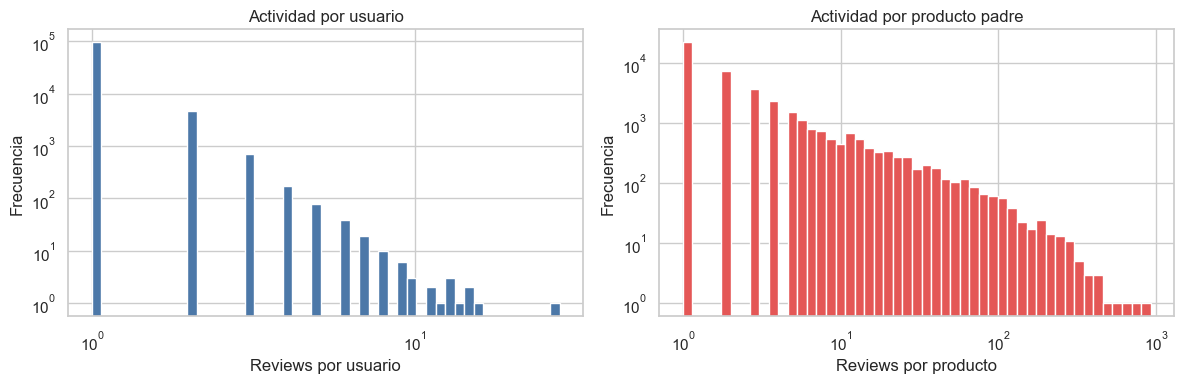

In [20]:
import numpy as np
user_activity_sample = user_activity.limit(100_000).toPandas()
item_activity_sample = item_activity.limit(100_000).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

min_user = user_activity_sample["count"].min()
max_user = user_activity_sample["count"].max()
bins_user = np.logspace(np.log10(min_user), np.log10(max_user), 50)

axes[0].hist(user_activity_sample["count"], bins=bins_user, color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Actividad por usuario")
axes[0].set_xlabel("Reviews por usuario")
axes[0].set_ylabel("Frecuencia")

min_item = item_activity_sample["count"].min()
max_item = item_activity_sample["count"].max()
bins_item = np.logspace(np.log10(min_item), np.log10(max_item), 50)

axes[1].hist(item_activity_sample["count"], bins=bins_item, color="#E45756")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Actividad por producto padre")
axes[1].set_xlabel("Reviews por producto")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()


In [21]:
top_users = user_activity.orderBy(F.desc("count")).limit(10).toPandas()
top_items = item_activity.orderBy(F.desc("count")).limit(10).toPandas()

display(top_users)
display(top_items)

,user_id,count
0,AGMWACNMAG74AXBF7IJ22IOZSZPA,39
1,AGIBXD3LM6HNDWWRTIOJHB5EKNFA,28
2,AHJRJCJMK3XVV4BSPBRAHIYEODWA,28
3,AGKOL2ISXEZE6EIPP5VIINFIHGLQ,20
4,AEWLQYBQDYWWUWK6UHHTNWO5AHYA,17
5,AHY7NSZXW4IUPQ2E4BPUOXUVP3UQ,16
6,AHF2J7WG4CPDF2IOVGZITSHQWFJA,16
7,AHYS63TR4TOZXK6QNCCWIO7MVSCQ,15
8,AGIR72F44THTLBTB46EUF5HCK6IA,15
9,AGWMT2QORZIH3ITWUO5CRPK2OH5A,15


,parent_asin,count
0,B01N3ASPNV,923
1,B0BN942894,878
2,B077GG9D5D,747
3,B000N5Z2L4,627
4,B0086VPUHI,592
5,B004RMK5QG,491
6,B07YBXFDYN,440
7,B00BGA9WK2,406
8,B07V8YSBFG,404
9,B0C5K4M7WJ,394


## 8. Votos utiles y compra verificada

Estas columnas no son imprescindibles para ALS, pero ayudan a decidir filtros de calidad o futuras features. Por ejemplo, `verified_purchase` puede reducir ruido, aunque tambien puede sesgar el dataset.

Nota: las columnas `title`, `text` e `images` existen en el parquet crudo, pero se dejan fuera del EDA principal porque son pesadas y pueden agotar la memoria local al convertir muestras a pandas o hacer agregaciones Spark.

In [22]:
quality_summary = df.select(
    F.mean(F.col("verified_purchase").cast("int")).alias("verified_purchase_rate"),
    F.min("helpful_vote").alias("min_helpful_vote"),
    F.max("helpful_vote").alias("max_helpful_vote"),
    F.mean("helpful_vote").alias("mean_helpful_vote"),
).toPandas()

quality_summary

,verified_purchase_rate,min_helpful_vote,max_helpful_vote,mean_helpful_vote
0,0.861219,-1,10369,1.227983


,verified_purchase,count
0,False,641808
1,True,3982807


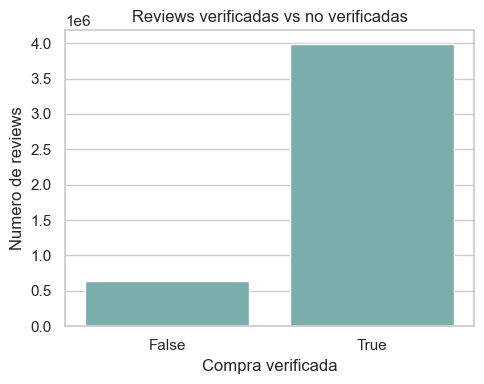

In [23]:
verified_dist = (
    df.groupBy("verified_purchase")
    .count()
    .orderBy("verified_purchase")
    .toPandas()
)

plt.figure(figsize=(5, 4))
sns.barplot(data=verified_dist, x="verified_purchase", y="count", color="#72B7B2")
plt.xlabel("Compra verificada")
plt.ylabel("Numero de reviews")
plt.title("Reviews verificadas vs no verificadas")
plt.tight_layout()

verified_dist

## 9. Comparar escenarios de limpieza

La tabla siguiente permite comparar reglas candidatas antes de cambiar el pipeline. Ajusta los umbrales y revisa cuantas filas, usuarios e items se conservan.

In [24]:
def keep_latest_user_item_review(input_df):
    window = Window.partitionBy("user_id", "parent_asin").orderBy(F.desc("timestamp"))
    return (
        input_df.withColumn("row_number", F.row_number().over(window))
        .filter(F.col("row_number") == 1)
        .drop("row_number")
    )


def filter_min_activity(input_df, min_user_reviews=2, min_item_reviews=2):
    users = input_df.groupBy("user_id").count().filter(F.col("count") >= min_user_reviews).select("user_id")
    items = input_df.groupBy("parent_asin").count().filter(F.col("count") >= min_item_reviews).select("parent_asin")
    return input_df.join(users, "user_id", "inner").join(items, "parent_asin", "inner")


def summarize_candidate(name, input_df):
    return {
        "scope": scenario_scope,
        "scenario": name,
        "rows": input_df.count(),
        "users": input_df.select("user_id").distinct().count(),
        "items": input_df.select("parent_asin").distinct().count(),
        "avg_rating": input_df.agg(F.mean("rating")).first()[0],
    }


scenario_source = df if RUN_EXPENSIVE_CHECKS else df.sample(False, SAMPLE_FRACTION, seed=123)
scenario_scope = "full_dataset" if RUN_EXPENSIVE_CHECKS else f"sample_{SAMPLE_FRACTION:.0%}"

base_recsys = scenario_source.select("user_id", "parent_asin", F.col("rating").cast("float"), "timestamp", "verified_purchase")

candidate_required = base_recsys.dropna(subset=["user_id", "parent_asin", "rating"])
candidate_valid_rating = candidate_required.filter(F.col("rating").between(1, 5))
candidate_latest = keep_latest_user_item_review(candidate_valid_rating)
candidate_min_2 = filter_min_activity(candidate_latest, min_user_reviews=2, min_item_reviews=2)
candidate_verified = candidate_latest.filter(F.col("verified_purchase") == True)

scenarios = [
    summarize_candidate("raw", base_recsys),
    summarize_candidate("required_fields", candidate_required),
    summarize_candidate("valid_rating_1_5", candidate_valid_rating),
    summarize_candidate("latest_per_user_parent_asin", candidate_latest),
    summarize_candidate("latest_min_user_item_2", candidate_min_2),
    summarize_candidate("latest_verified_only", candidate_verified),
]

scenario_pd = pd.DataFrame(scenarios)
scenario_pd["row_retention"] = scenario_pd["rows"] / scenario_pd.loc[scenario_pd["scenario"] == "raw", "rows"].iloc[0]
scenario_pd

,scope,scenario,rows,users,items,avg_rating,row_retention
0,sample_5%,raw,231526,215816,44149,4.047714,1.000000
1,sample_5%,required_fields,231526,215816,44149,4.047714,1.000000
2,sample_5%,valid_rating_1_5,231526,215816,44149,4.047714,1.000000
3,sample_5%,latest_per_user_parent_asin,231319,215816,44149,4.047739,0.999106
4,sample_5%,latest_min_user_item_2,24313,11699,10220,4.231563,0.105012
5,sample_5%,latest_verified_only,199149,188545,39447,4.098846,0.860158


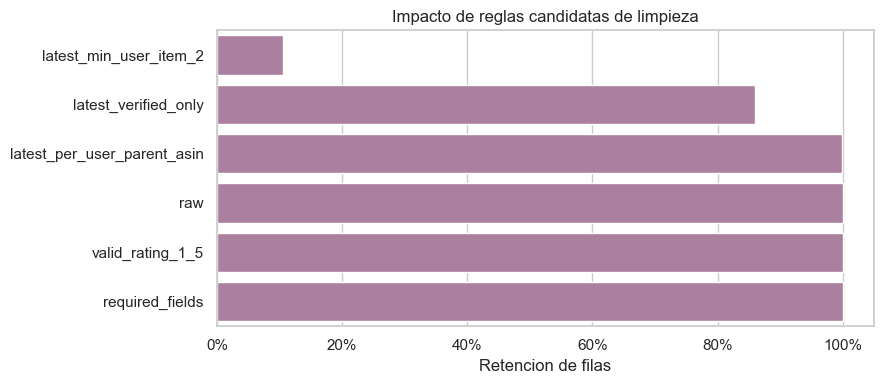

In [25]:
plot_scenarios = scenario_pd.sort_values("row_retention", ascending=True)

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_scenarios, x="row_retention", y="scenario", color="#B279A2")
plt.gca().xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.xlabel("Retencion de filas")
plt.ylabel("")
plt.title("Impacto de reglas candidatas de limpieza")
plt.tight_layout()

## 10. Dataset candidato para modelado

Esta celda crea una version candidata sin guardarla. Si las metricas anteriores son razonables, las reglas deberian moverse al pipeline de Kedro en `src/amazon_recsys/pipelines/data_processing/nodes.py`.

In [26]:
clean_candidate = (
    candidate_latest
    .select("user_id", "parent_asin", "rating")
    .dropna(subset=["user_id", "parent_asin", "rating"])
)

clean_candidate.printSchema()
clean_candidate.limit(10).toPandas()

root
 |-- user_id: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: float (nullable = true)



,user_id,parent_asin,rating
0,AE2227QSJSF6HV3XTTIGQAPA6WHQ,B004XDCJ4A,5.0
1,AE222TIYCUU6T4DZZZB6I4LE6ZVQ,B0086VPUHI,5.0
2,AE225DFHMBOAA7LXWEZY3XGBZC5Q,B0136JPA56,4.0
3,AE22B4CGZRPHTJHDB4ZIAMABBLTQ,B0771ZXXV6,1.0
4,AE22BPP6UHGKZW4CTPBIQFQ2AXEQ,B01GY35HKE,1.0
5,AE22ERJ7YI3QH427LG2TSMGI6XAA,B087SHFL9B,5.0
6,AE22FB2VMJBOG5YMPDWVV4RCAMMQ,B000PMGN2M,5.0
7,AE22J2LT6YKE363TDWMGSBPAYPHQ,B0B9MJK753,5.0
8,AE22JEDLLUPFXFB7RE6ATCMGXZYQ,B0714FFZD8,1.0
9,AE22KNY5CIUZ4TMKXJKKVXP4JHMQ,B01FMQ3LMU,2.0


## 11. Decisiones de limpieza a cerrar

Checklist recomendado antes de editar el pipeline:

- Confirmar item id: usar `parent_asin` para agrupar variantes o `asin` para productos concretos.
- Confirmar duplicados: conservar review mas reciente por `user_id` + `parent_asin`, o agregar rating medio.
- Confirmar filtro de rating: conservar solo valores entre 1 y 5.
- Confirmar minimo de actividad: evaluar umbrales como 2, 3 o 5 interacciones por usuario/item segun retencion.
- Confirmar si `verified_purchase == True` sera filtro duro o solo feature de calidad.
- Confirmar estrategia temporal: usar fechas para split train/test si se evaluara recomendacion con holdout temporal.

Decision base sugerida para empezar: `user_id`, `parent_asin`, `rating`; eliminar nulos; filtrar ratings 1-5; resolver duplicados manteniendo la review mas reciente. Dejar `verified_purchase` y minimos de actividad como experimentos porque pueden reducir mucho la cobertura.